# DQN with Acrobot-v1 Environment

This notebook loads [config.yaml](config.yaml) and trains the `QAgent` on `Acrobot-v1` using the Gymnassium API for envrionment.

Acrobot has a `Box(6,)` **observation space** and a `Discrete(3)` **action space**, so DQN uses the continuous state and the native discrete actions while training, during analysis we break it down based on our analysis discretisation config to look at the various statistics.

## Imports

In [1]:

import sys, pathlib, yaml
from functools import partial
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SRC = pathlib.Path.cwd().parents[1] / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from environments.base_env import make_environment
from agents.q_agent import QAgent
from training import dqn_training_loop
from analysis.low_rank.hankel_policy import hankel_rollout
from analysis.low_rank.tabular_q_matrix import q_matrix_dqn
from analysis.low_rank.rank import plot_matrix_spectra, row_rank_property_check

## Reading the `config` file

In [2]:
# Reading the experiment config file
with open("config.yaml") as f:
    cfg = yaml.safe_load(f)

# Gathering torch backend and experiment seed
dev = cfg["experiment"]["device"]
device = dev if (dev != "mps" or torch.backends.mps.is_available()) else "cpu"
seed = cfg["experiment"]["seed"]
torch.manual_seed(seed)
np.random.seed(seed)

cfg

{'experiment': {'name': 'dqn_acrobot', 'seed': 52, 'device': 'mps'},
 'environment': {'name': 'Acrobot-v1',
  'render_mode': None,
  'discrete_config': None,
  'normalise': {'action': {}, 'state': {}},
  'clip': {'action': False, 'state': []}},
 'network': {'hidden_sizes': [128, 128]},
 'agent': {'replay_buffer_capacity': 10000,
  'batch_size': 128,
  'nn_learning_rate': 0.0003,
  'eps_start': 1.0,
  'eps_min': 0.05,
  'decay_rate': 0.99995,
  'discount_factor': 0.99,
  'TD_LR': 0.005,
  'buffer_util': 1},
 'training': {'no_episodes': 500,
  'target_network_update_steps': 2,
  'train_frequency_steps': 200},
 'analysis': {'ep_freq': 50,
  'methods': [{'name': 'hankel_rollout', 'kwargs': {'seed': 52}},
   {'name': 'q_matrix_dqn',
    'kwargs': {'state_discretisation': [8, 8, 8, 8, 8, 8],
     'batch_size': 64}}]}}

## Creating the Envrionment

In [3]:
env_cfg = cfg["environment"]
env = make_environment(
    env_cfg["name"],
    render_mode=env_cfg["render_mode"],
    discrete_config=env_cfg["discrete_config"],   # None -> no discretisation
    normalise=env_cfg["normalise"],               # {action:{}, state:{}} -> no rescaling
    clip=env_cfg["clip"],
)
obs_dim = env.observation_space.shape[0]         
n_actions = env.action_space.n                    
print("obs_dim:", obs_dim, "n_actions:", n_actions)

obs_dim: 6 n_actions: 3


## Creating the Agent

In [4]:
class QNetwork(nn.Module):
    """Maps a state (obs_dim,) -> Q-values (n_actions,). Built by QAgent via q_network(**nn_extra_kwargs)."""
    def __init__(self, in_dim, out_dim, hidden_sizes=(128, 128)):
        super().__init__()
        layers, last = [], in_dim
        for h in hidden_sizes:
            layers += [nn.Linear(last, h), nn.ReLU()]
            last = h
        layers.append(nn.Linear(last, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [5]:
a = cfg["agent"]
nn_extra_kwargs = {
    "in_dim": obs_dim,
    "out_dim": n_actions,
    "hidden_sizes": cfg["network"]["hidden_sizes"],
}
agent = QAgent(
    replay_buffer_capacity=a["replay_buffer_capacity"],
    q_network=QNetwork,
    batch_size=a["batch_size"],
    nn_learning_rate=a["nn_learning_rate"],
    nn_extra_kwargs=nn_extra_kwargs,
    env=env,
    eps_start=a["eps_start"],
    eps_min=a["eps_min"],
    decay_rate=a["decay_rate"],
    discount_factor=a["discount_factor"],
    device=device,
    TD_LR=a["TD_LR"],
    buffer_util=a["buffer_util"],
)

## Analysis (Low Rank)

In [6]:
analysis = cfg["analysis"]

# registry mapping config.yaml strings for methods to callable function objects
analysis_methods = {
    "hankel_rollout": hankel_rollout,
    "q_matrix_dqn": q_matrix_dqn,
}

# Each config entry is {name, kwargs}. Resolve `name` to its callable and pre-bind
# the config-supplied `kwargs` with functools.partial, leaving only the runtime
# args (agent, env) for the training loop to inject at call time.
analysis["methods"] = [
    partial(analysis_methods[m["name"]], **m.get("kwargs", {}))
    for m in analysis["methods"]
]
analysis

{'ep_freq': 50,
 'methods': [functools.partial(<function hankel_rollout at 0x11f1e7ec0>, seed=52),
  functools.partial(<function q_matrix_dqn at 0x11f1e7d80>, state_discretisation=[8, 8, 8, 8, 8, 8], batch_size=64)]}

## Agent Training 

  0%|          | 0/500 [00:00<?, ?it/s]

episode 0 avg_rewarg: -50.0
****************************Hankel Value Function****************************


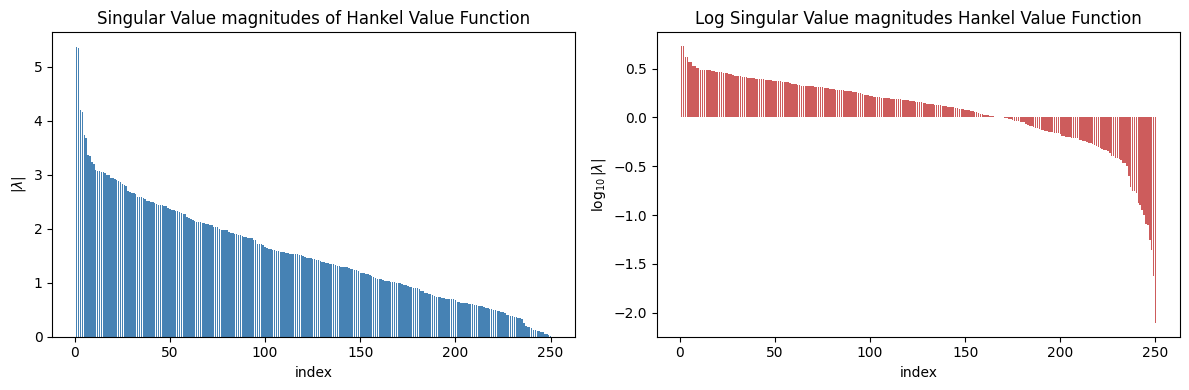

eff_rank: 133, stable_rank: 28.45, shape: (251, 250), non-zero rows :251, non-zero cols:250
top-r leverage spread: min=0.003414 max=0.004425 (uniform would be 0.003984)
row-space coherence score: 1.111
****************************Q-function****************************


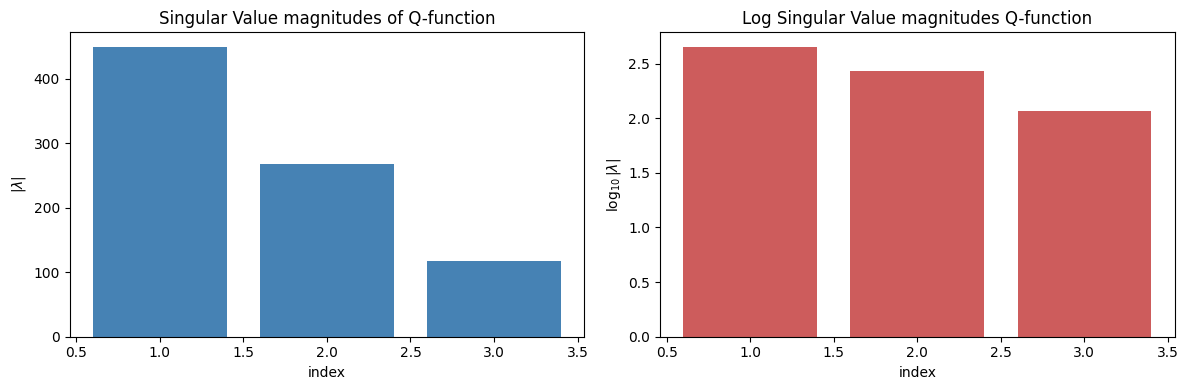

  0%|          | 1/500 [00:06<56:10,  6.75s/it]

eff_rank: 2, stable_rank: 1.42, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: min=2.784e-08 max=1.732e-05 (uniform would be 3.815e-06)
row-space coherence score: 4.54


  2%|▏         | 11/500 [00:16<09:13,  1.13s/it]

episode 10 avg_rewarg: -500.0


  4%|▍         | 21/500 [00:31<12:58,  1.63s/it]

...

episode 30 avg_rewarg: -500.0


  8%|▊         | 41/500 [01:07<13:49,  1.81s/it]

episode 40 avg_rewarg: -500.0


 10%|█         | 50/500 [01:16<07:10,  1.05it/s]

episode 50 avg_rewarg: -237.5
****************************Hankel Value Function****************************


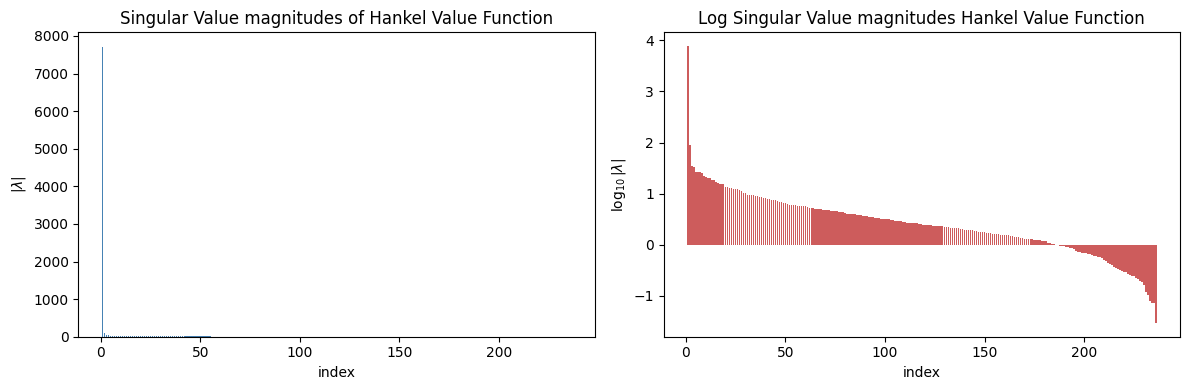

eff_rank: 1, stable_rank: 1.00, shape: (236, 236), non-zero rows :236, non-zero cols:236
top-r leverage spread: min=0.003913 max=0.004392 (uniform would be 0.004237)
row-space coherence score: 1.037
****************************Q-function****************************


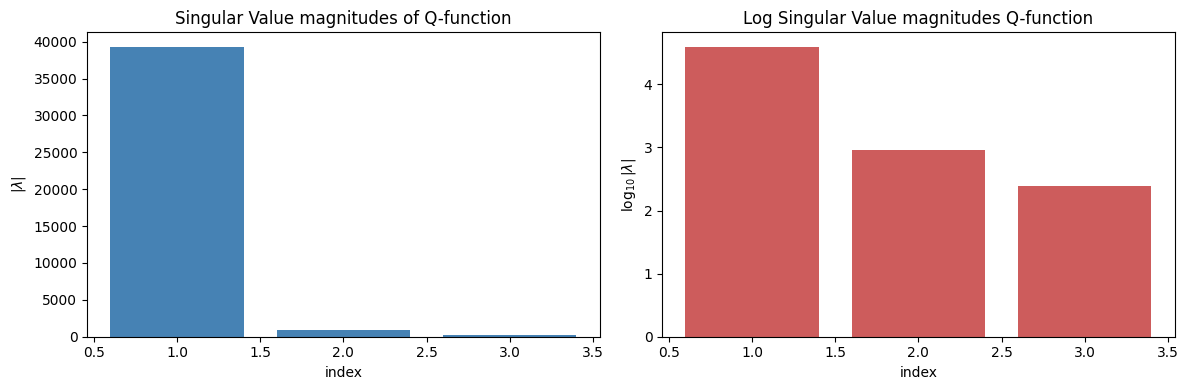

 10%|█         | 51/500 [01:21<15:58,  2.13s/it]

eff_rank: 1, stable_rank: 1.00, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: min=3.008e-07 max=1.455e-05 (uniform would be 3.815e-06)
row-space coherence score: 3.815


 12%|█▏        | 61/500 [01:28<05:05,  1.44it/s]

episode 60 avg_rewarg: -199.6


 14%|█▍        | 71/500 [01:34<04:06,  1.74it/s]

...

episode 80 avg_rewarg: -203.7


 18%|█▊        | 91/500 [01:47<02:59,  2.28it/s]

episode 90 avg_rewarg: -144.4


 20%|██        | 100/500 [01:51<03:10,  2.10it/s]

episode 100 avg_rewarg: -121.1
****************************Hankel Value Function****************************


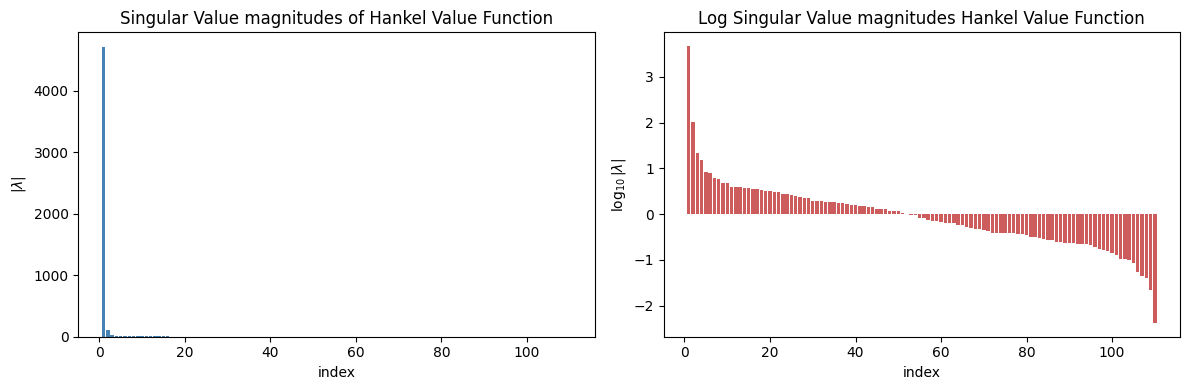

eff_rank: 1, stable_rank: 1.00, shape: (111, 110), non-zero rows :111, non-zero cols:110
top-r leverage spread: min=0.00793 max=0.009438 (uniform would be 0.009009)
row-space coherence score: 1.048
****************************Q-function****************************


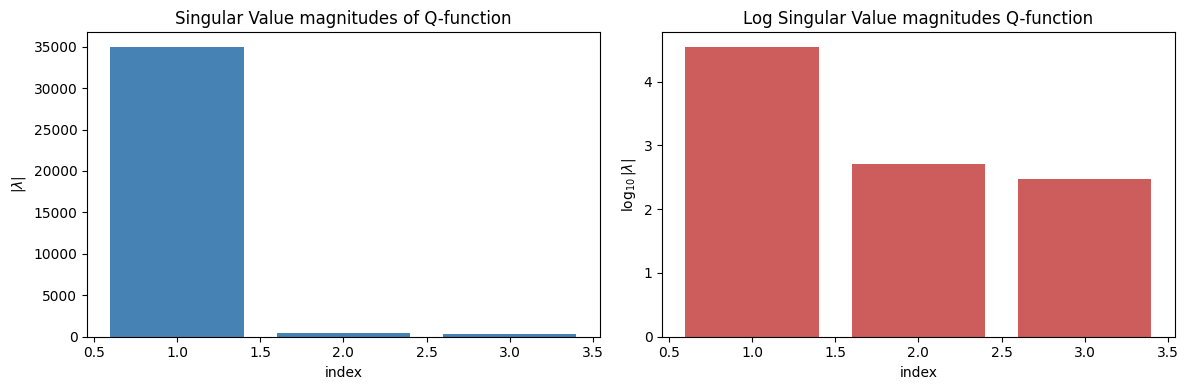

 20%|██        | 101/500 [01:55<11:02,  1.66s/it]

eff_rank: 1, stable_rank: 1.00, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: min=2.174e-07 max=1.227e-05 (uniform would be 3.815e-06)
row-space coherence score: 3.215


 22%|██▏       | 111/500 [02:00<03:32,  1.83it/s]

episode 110 avg_rewarg: -123.9


 24%|██▍       | 121/500 [02:05<02:31,  2.50it/s]

...

episode 130 avg_rewarg: -112.5


 28%|██▊       | 141/500 [02:16<02:52,  2.08it/s]

episode 140 avg_rewarg: -141.7


 30%|███       | 150/500 [02:19<02:34,  2.27it/s]

episode 150 avg_rewarg: -113.4
****************************Hankel Value Function****************************


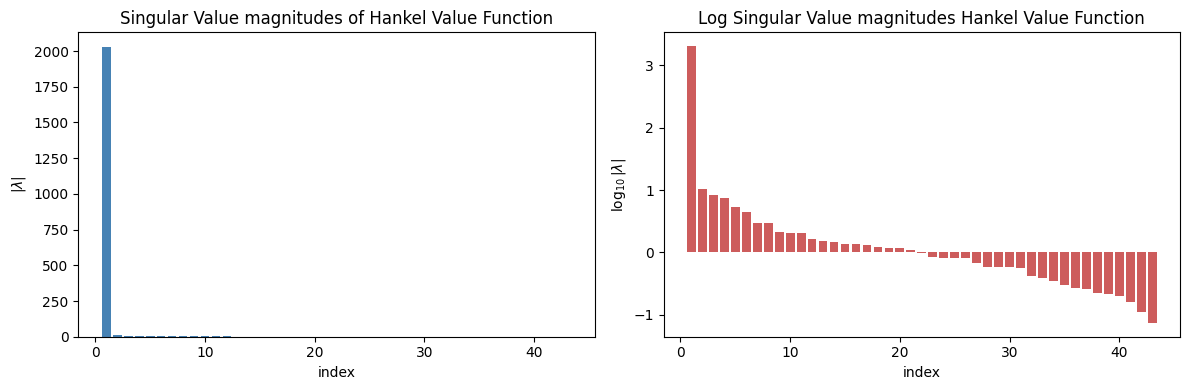

eff_rank: 1, stable_rank: 1.00, shape: (44, 43), non-zero rows :44, non-zero cols:43
top-r leverage spread: min=0.02025 max=0.02491 (uniform would be 0.02273)
row-space coherence score: 1.096
****************************Q-function****************************


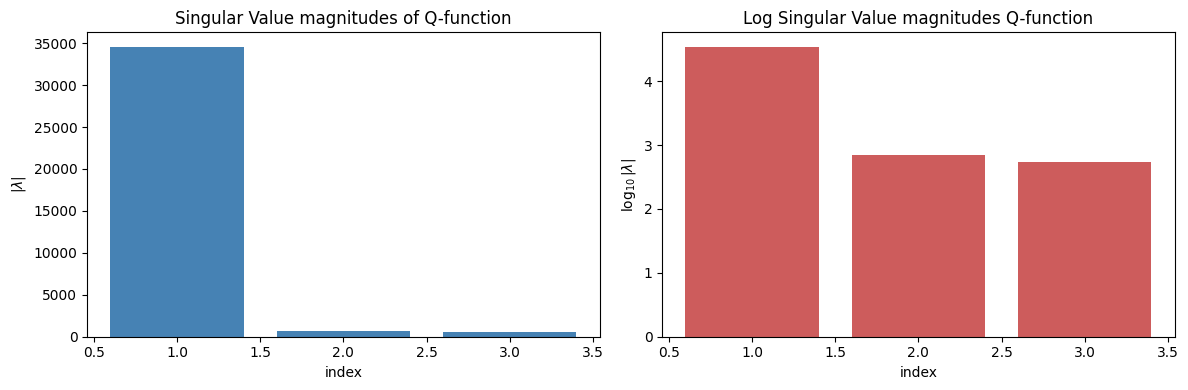

 30%|███       | 151/500 [02:24<09:41,  1.67s/it]

eff_rank: 1, stable_rank: 1.00, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: min=9.189e-09 max=1.076e-05 (uniform would be 3.815e-06)
row-space coherence score: 2.822


 32%|███▏      | 161/500 [02:29<02:21,  2.39it/s]

episode 160 avg_rewarg: -129.9


 34%|███▍      | 171/500 [02:33<02:35,  2.12it/s]

...

episode 180 avg_rewarg: -90.0


 38%|███▊      | 191/500 [02:40<01:40,  3.09it/s]

episode 190 avg_rewarg: -87.1


 40%|████      | 200/500 [02:44<02:19,  2.15it/s]

episode 200 avg_rewarg: -100.0
****************************Hankel Value Function****************************


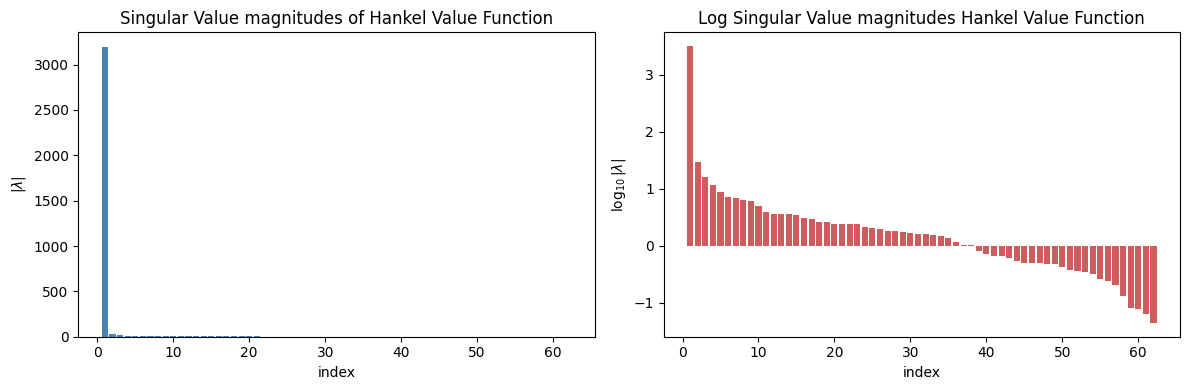

eff_rank: 1, stable_rank: 1.00, shape: (63, 62), non-zero rows :63, non-zero cols:62
top-r leverage spread: min=0.01374 max=0.01742 (uniform would be 0.01587)
row-space coherence score: 1.098
****************************Q-function****************************


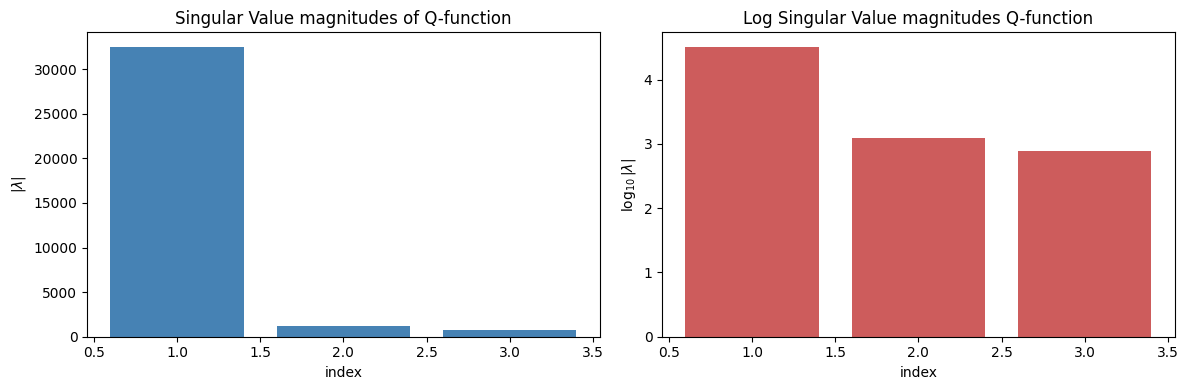

 40%|████      | 201/500 [02:48<07:36,  1.53s/it]

eff_rank: 1, stable_rank: 1.00, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: min=2.729e-16 max=1.156e-05 (uniform would be 3.815e-06)
row-space coherence score: 3.031


 42%|████▏     | 212/500 [02:52<01:40,  2.86it/s]

episode 210 avg_rewarg: -99.4


 44%|████▍     | 221/500 [02:55<01:25,  3.25it/s]

...

episode 230 avg_rewarg: -99.3


 48%|████▊     | 241/500 [03:03<01:22,  3.13it/s]

episode 240 avg_rewarg: -124.4


 50%|█████     | 250/500 [03:07<01:31,  2.73it/s]

episode 250 avg_rewarg: -105.4
****************************Hankel Value Function****************************


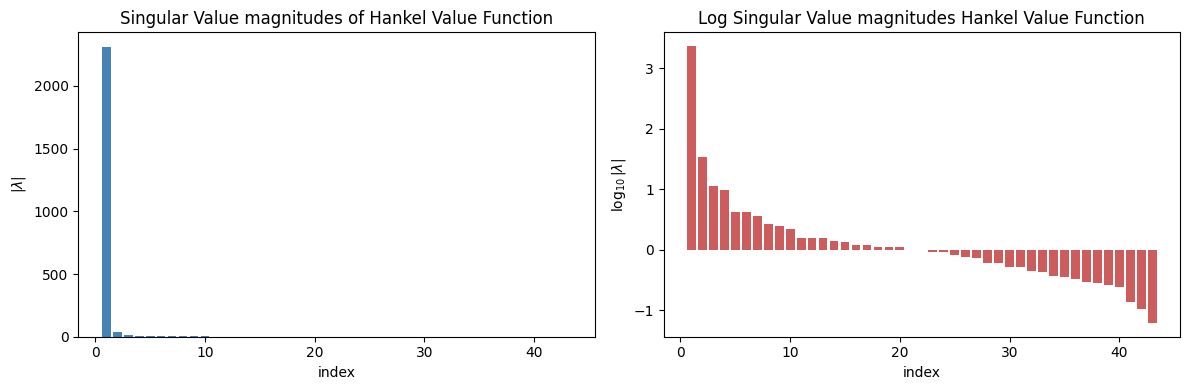

eff_rank: 1, stable_rank: 1.00, shape: (43, 43), non-zero rows :43, non-zero cols:43
top-r leverage spread: min=0.01977 max=0.02569 (uniform would be 0.02326)
row-space coherence score: 1.105
****************************Q-function****************************


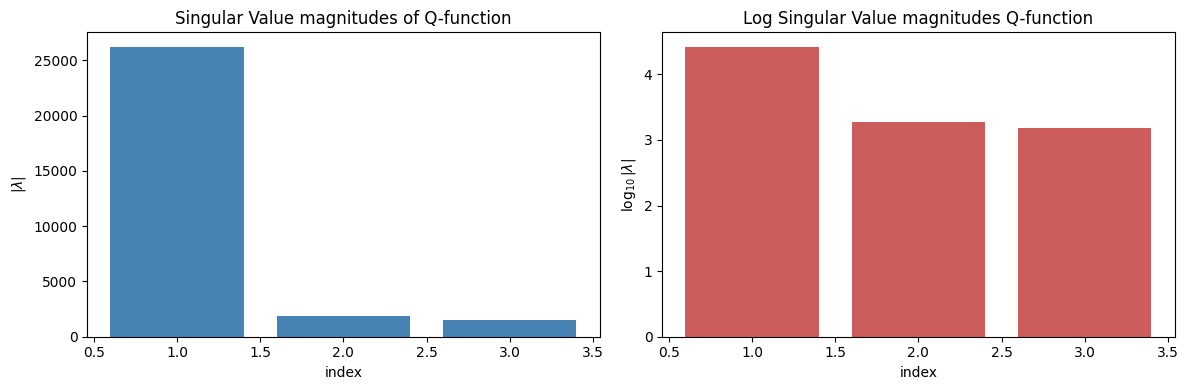

 50%|█████     | 252/500 [03:12<04:38,  1.12s/it]

eff_rank: 1, stable_rank: 1.01, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: min=1.342e-16 max=1.674e-05 (uniform would be 3.815e-06)
row-space coherence score: 4.388


 52%|█████▏    | 262/500 [03:16<01:26,  2.76it/s]

episode 260 avg_rewarg: -100.2


 54%|█████▍    | 271/500 [03:19<01:04,  3.56it/s]

...

episode 280 avg_rewarg: -82.9


 58%|█████▊    | 291/500 [03:26<01:24,  2.48it/s]

episode 290 avg_rewarg: -111.1


 60%|██████    | 300/500 [03:29<01:04,  3.10it/s]

episode 300 avg_rewarg: -90.6
****************************Hankel Value Function****************************


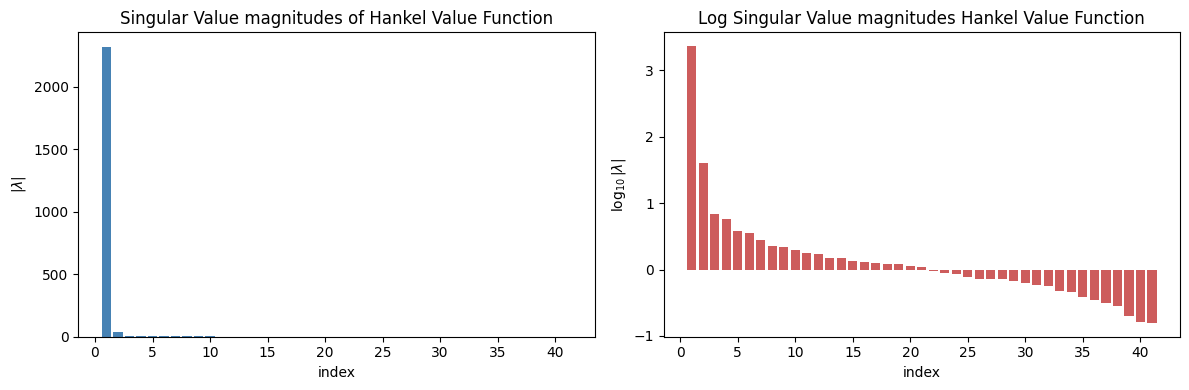

eff_rank: 1, stable_rank: 1.00, shape: (42, 41), non-zero rows :42, non-zero cols:41
top-r leverage spread: min=0.01949 max=0.027 (uniform would be 0.02381)
row-space coherence score: 1.134
****************************Q-function****************************


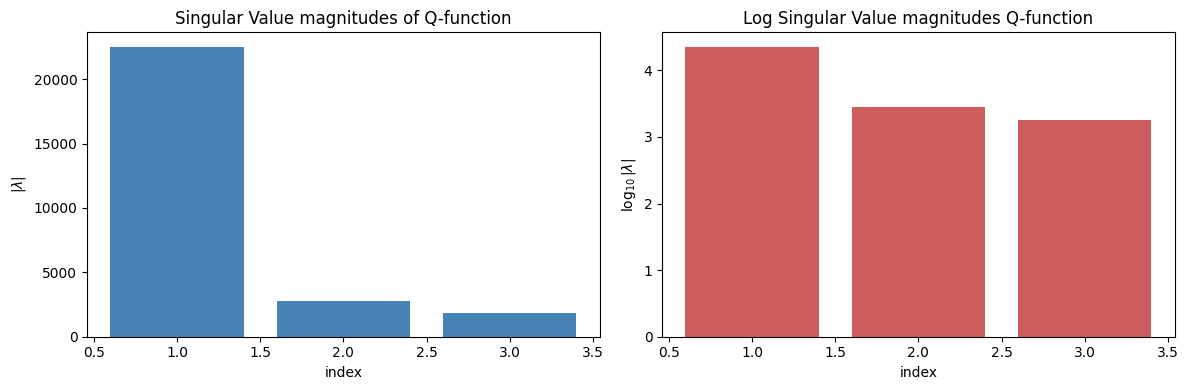

 60%|██████    | 302/500 [03:33<03:27,  1.05s/it]

eff_rank: 1, stable_rank: 1.02, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: min=1.033e-16 max=2.489e-05 (uniform would be 3.815e-06)
row-space coherence score: 6.526


 62%|██████▏   | 312/500 [03:37<01:05,  2.85it/s]

episode 310 avg_rewarg: -95.4


 64%|██████▍   | 322/500 [03:41<01:12,  2.45it/s]

...

episode 330 avg_rewarg: -107.1


 68%|██████▊   | 341/500 [03:48<01:02,  2.53it/s]

episode 340 avg_rewarg: -95.0


 70%|███████   | 350/500 [03:51<00:52,  2.85it/s]

episode 350 avg_rewarg: -85.5
****************************Hankel Value Function****************************


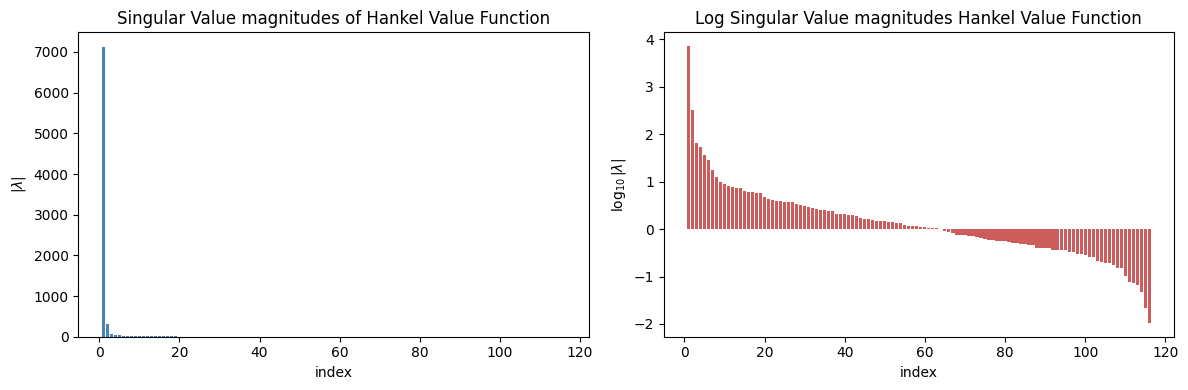

eff_rank: 1, stable_rank: 1.00, shape: (116, 116), non-zero rows :116, non-zero cols:116
top-r leverage spread: min=0.006708 max=0.009382 (uniform would be 0.008621)
row-space coherence score: 1.088
****************************Q-function****************************


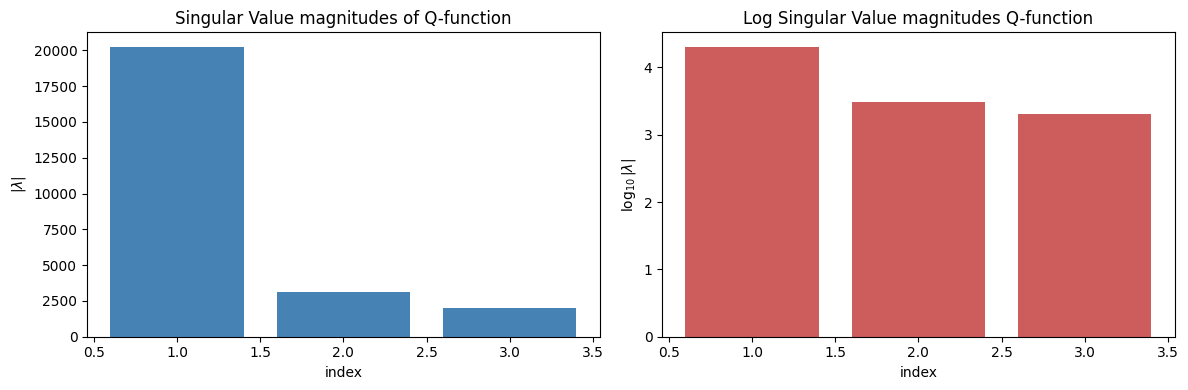

 70%|███████   | 351/500 [03:56<03:59,  1.60s/it]

eff_rank: 1, stable_rank: 1.03, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: min=5.789e-17 max=3.403e-05 (uniform would be 3.815e-06)
row-space coherence score: 8.921


 72%|███████▏  | 361/500 [03:59<00:41,  3.33it/s]

episode 360 avg_rewarg: -96.8


 74%|███████▍  | 371/500 [04:02<00:34,  3.69it/s]

...

episode 380 avg_rewarg: -93.7


 78%|███████▊  | 391/500 [04:10<01:03,  1.71it/s]

episode 390 avg_rewarg: -121.1


 80%|████████  | 400/500 [04:14<00:39,  2.54it/s]

episode 400 avg_rewarg: -98.7
****************************Hankel Value Function****************************


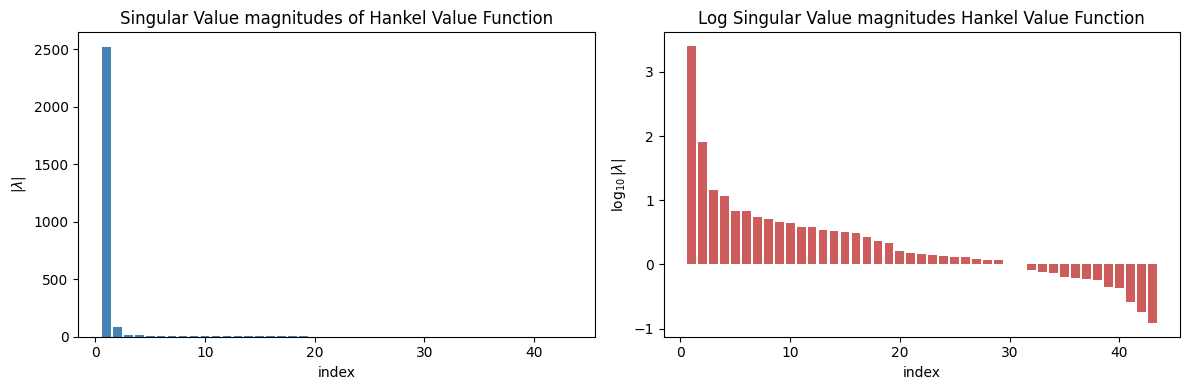

eff_rank: 1, stable_rank: 1.00, shape: (43, 43), non-zero rows :43, non-zero cols:43
top-r leverage spread: min=0.01677 max=0.02783 (uniform would be 0.02326)
row-space coherence score: 1.197
****************************Q-function****************************


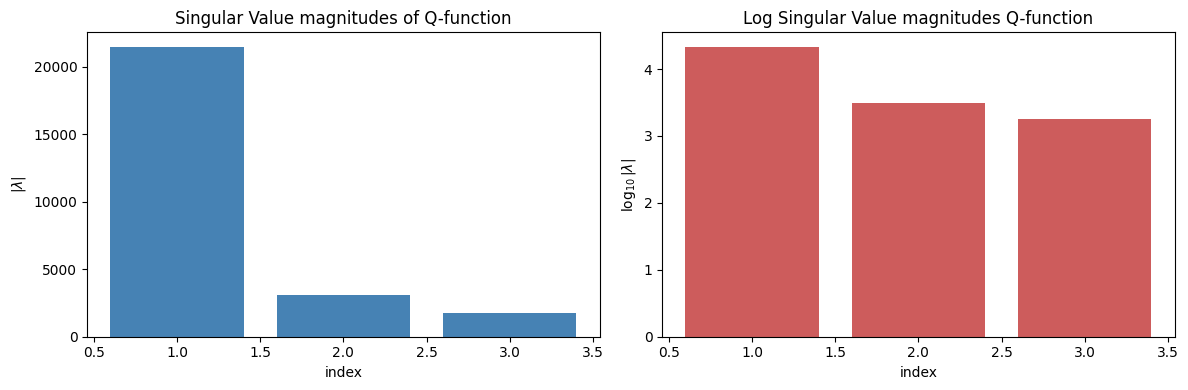

 80%|████████  | 401/500 [04:18<02:10,  1.32s/it]

eff_rank: 1, stable_rank: 1.03, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: min=2.113e-17 max=3.265e-05 (uniform would be 3.815e-06)
row-space coherence score: 8.56


 82%|████████▏ | 412/500 [04:21<00:22,  3.86it/s]

episode 410 avg_rewarg: -75.8


 84%|████████▍ | 421/500 [04:24<00:22,  3.55it/s]

...

episode 430 avg_rewarg: -93.2


 88%|████████▊ | 441/500 [04:31<00:18,  3.25it/s]

episode 440 avg_rewarg: -87.1


 90%|█████████ | 450/500 [04:34<00:16,  2.96it/s]

episode 450 avg_rewarg: -84.2
****************************Hankel Value Function****************************


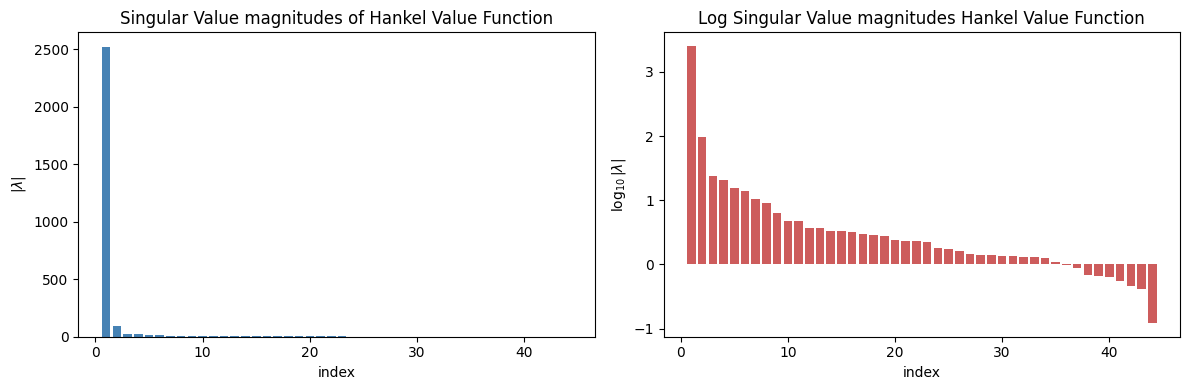

eff_rank: 1, stable_rank: 1.00, shape: (44, 44), non-zero rows :44, non-zero cols:44
top-r leverage spread: min=0.01498 max=0.0288 (uniform would be 0.02273)
row-space coherence score: 1.267
****************************Q-function****************************


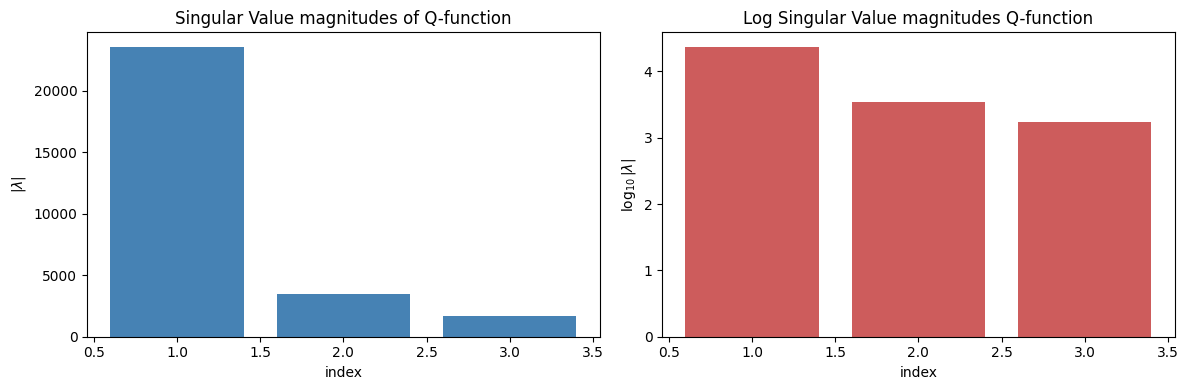

 90%|█████████ | 452/500 [04:38<00:51,  1.08s/it]

eff_rank: 1, stable_rank: 1.03, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: min=6.446e-18 max=2.814e-05 (uniform would be 3.815e-06)
row-space coherence score: 7.377


 92%|█████████▏| 462/500 [04:42<00:14,  2.71it/s]

episode 460 avg_rewarg: -83.4


 94%|█████████▍| 472/500 [04:46<00:09,  2.93it/s]

...

 96%|█████████▋| 482/500 [04:49<00:04,  3.87it/s]

episode 480 avg_rewarg: -85.7


 98%|█████████▊| 492/500 [04:52<00:02,  3.10it/s]

episode 490 avg_rewarg: -91.3


100%|██████████| 500/500 [04:55<00:00,  1.69it/s]


In [7]:
t = cfg["training"]
rewards = dqn_training_loop(
    agent, env,
    no_episodes=t["no_episodes"],
    target_network_update_steps=t["target_network_update_steps"],
    train_frequency_steps = t["train_frequency_steps"],
    np_seed=seed,
    analysis_config = analysis
)

## Training and Analysis Plots (now with pi*(theeta))

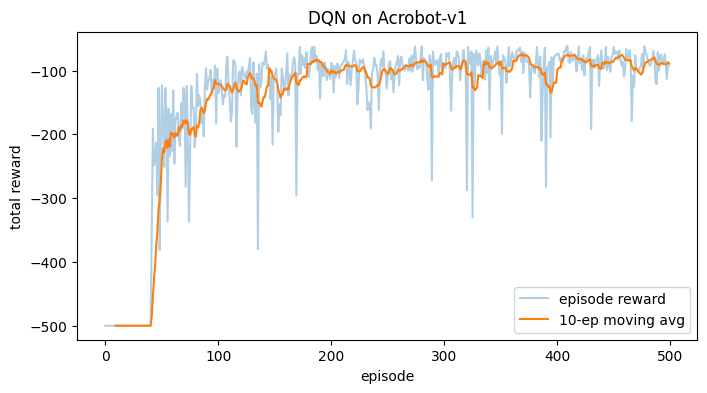

In [8]:
rewards = np.asarray(rewards, dtype=float)
plt.figure(figsize=(8, 4))
plt.plot(rewards, alpha=0.35, label="episode reward")
if len(rewards) >= 10:
    k = 10
    ma = np.convolve(rewards, np.ones(k) / k, mode="valid")
    plt.plot(range(k - 1, len(rewards)), ma, label=f"{k}-ep moving avg")
plt.xlabel("episode"); plt.ylabel("total reward"); plt.title("DQN on Acrobot-v1")
plt.legend(); plt.show()

Hankel Value Function


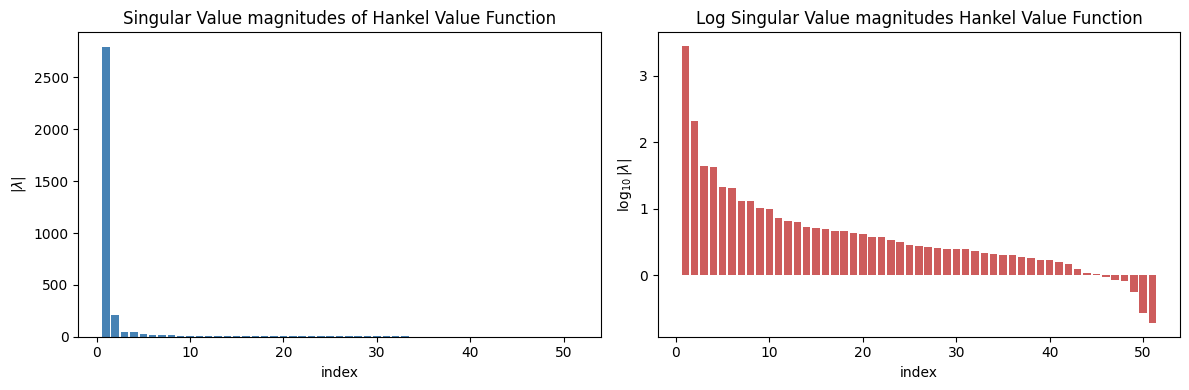

eff_rank: 1, stable_rank: 1.01, shape: (52, 51), non-zero rows :52, non-zero cols:51
top-r leverage spread: min=0.009415 max=0.02701 (uniform would be 0.01923)
row-space coherence score: 1.404
Q-function


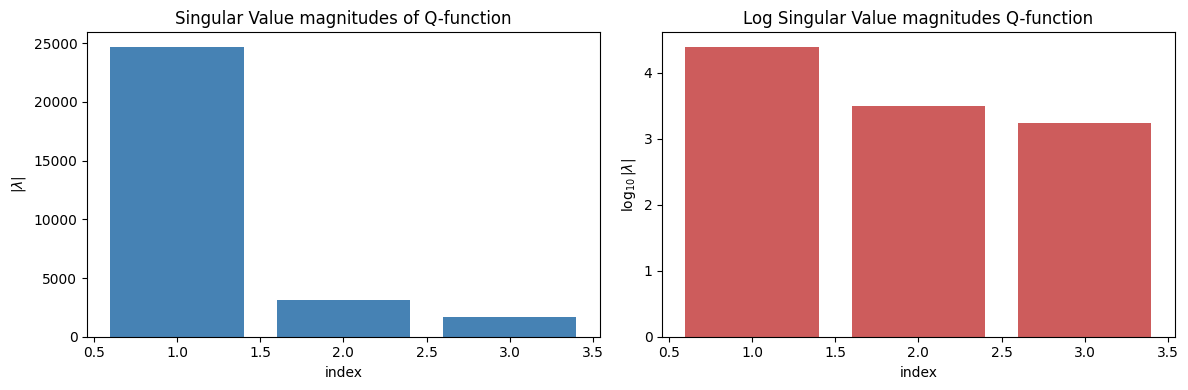

eff_rank: 1, stable_rank: 1.02, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: min=2.77e-19 max=2.877e-05 (uniform would be 3.815e-06)
row-space coherence score: 7.541


In [9]:
for method,name in zip(analysis["methods"], ['Hankel Value Function','Q-function']):
    print(name)
    matrix = method(agent=agent, env=env)
    r, sr, shape, irs, rc, nzc, nzr = row_rank_property_check(matrix, name)
    # returns effective_rank, stable_rank, shape, irs (normalised top-r leverage per row),
    # rc = coherence of the rank-r row space ((m/rank)*max leverage, in [1, m/rank]),
    # nzc and nzr are the number of non zero columns and rows in the original matrix.
    print(f"eff_rank: {r}, stable_rank: {sr:.2f}, shape: {shape}, non-zero rows :{nzr}, non-zero cols:{nzc}")
    print(f"top-r leverage spread: min={irs.min():.4g} max={irs.max():.4g} (uniform would be {1.0/shape[0]:.4g})")
    print(f"row-space coherence score: {rc:.4g}")